In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="py_mini_racer")
warnings.filterwarnings("ignore", message=".*pkg_resources is deprecated.*")
warnings.filterwarnings("ignore", module="baostock")
import os
from dotenv import load_dotenv
from utils import ROOT_DIR, query_zz500_stocks
import clickhouse_connect
import pandas as pd
import numpy as np
import torch
from script.alphanet import AlphaNet, get_trade_calender, process_raw_data
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

In [2]:
load_dotenv()
host = os.getenv('CH_HOST')

client = clickhouse_connect.get_client(
    host=host,
    port=8123,
    username='default',
    password='',
    database='quant',
    compress=False,
    connect_timeout=60,
    send_receive_timeout=6000
)

In [3]:
backtest_start_date, backtest_end_date = '2022-01-01', '2026-01-01'
zz500_code = query_zz500_stocks()['code']
zz500_code = [code[3:] for code in zz500_code]
code_str = ", ".join(f"'{code}'" for code in zz500_code)

raw_df = client.query_df(f"""
    SELECT * FROM quant.v_stock_daily_online
    WHERE trade_date BETWEEN '{backtest_start_date}' AND '{backtest_end_date}'
        AND stock_code IN ({code_str})
    ORDER BY trade_date, stock_code
""")

trade_calender = get_trade_calender(backtest_start_date, backtest_end_date)
X, y_raw = process_raw_data(raw_df, trade_calender, keep_time_series=True)

step = 10
X_trade = X[::step, ...]
y_trade = y_raw[::step, ...]

In [4]:
COMMISSION_RATE = 0.002
stocks = sorted(raw_df['stock_code'].unique())
S = len(stocks)
T, S = y_trade.shape
group_returns = np.full((T, 5), np.nan)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AlphaNet(input_channels=8, op_d=10, hidden_dim=30, window_size=30).to(device)
model_path = ROOT_DIR / '1-weights' / 'best_alpha_net.pth'
model.load_state_dict(torch.load(model_path, map_location=device))
prev_holdings = [set() for _ in range(5)]
for i, (X_cs, y_cs) in enumerate(zip(X_trade, y_trade)):
    cs_valid = ~np.any(np.isnan(X_cs), axis=(1, 2)) & ~np.isnan(y_cs)
    valid_indices = np.where(cs_valid)[0]
    if len(valid_indices) == 0:
        for g in range(5):
            group_returns[i, g] = 0.0
        continue
    X_valid = X_cs[cs_valid]
    y_valid = y_cs[cs_valid]
    with torch.no_grad():
        scores = model(torch.tensor(X_valid, dtype=torch.float32, device=device)
                       ).squeeze().cpu().numpy()
    ranks = pd.Series(scores).rank(pct=True, method='first')
    groups = np.floor(ranks * 5).clip(0, 4).astype(int)
    curr_holdings = [set() for _ in range(5)]
    for idx, g in enumerate(groups):
        global_idx = valid_indices[idx]
        curr_holdings[g].add(global_idx)
    for g in range(5):
        mask = (groups == g)
        if mask.sum() == 0:
            group_returns[i, g] = 0.0
            continue
        gross_ret = np.mean(y_valid[mask])
        prev_set = prev_holdings[g]
        curr_set = curr_holdings[g]
        if i == 0:
            cost_rate = COMMISSION_RATE
        else:
            n_new = len(curr_set)
            n_old = len(prev_set)
            if n_new == 0:
                cost_rate = 0.0
            else:
                overlap = len(curr_set & prev_set)
                turnover = 1.0 - overlap / n_new
                cost_rate = 2 * COMMISSION_RATE * turnover
        net_ret = gross_ret - cost_rate
        group_returns[i, g] = net_ret
    prev_holdings = curr_holdings
group_returns = np.nan_to_num(group_returns, nan=0.0)
cum_returns = np.cumprod(1 + group_returns, axis=0)

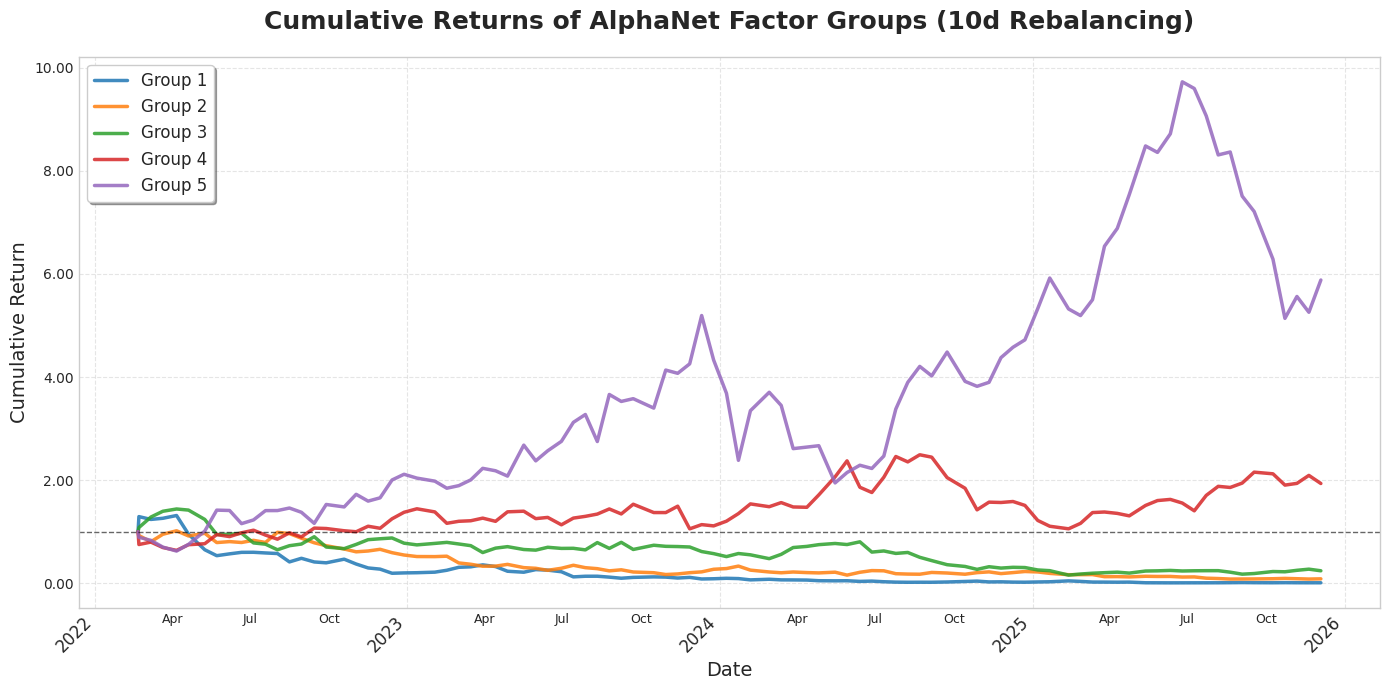

In [5]:
trade_dates = pd.to_datetime(trade_calender['trade_date'].values)
window_size = 30
start_idx = window_size - 1
indices = np.arange(start_idx, start_idx + T * step, step)[:T]
rebalance_dates = trade_dates[indices]
initial_date = rebalance_dates[0] - pd.Timedelta(days=1)
plot_dates = pd.DatetimeIndex([initial_date] + list(rebalance_dates))
plot_values = np.vstack([np.ones(5), cum_returns])
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 7))
colors = plt.cm.tab10.colors
for g in range(5):
    ax.plot(plot_dates, plot_values[:, g], color=colors[g], linewidth=2.5,
            label=f'Group {g+1}', alpha=0.85)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=12)
plt.setp(ax.xaxis.get_minorticklabels(), fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.set_title('Cumulative Returns of AlphaNet Factor Groups (10d Rebalancing)',
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Cumulative Return', fontsize=14)
ax.legend(loc='upper left', frameon=True, fontsize=12, shadow=True)
ax.grid(True, linestyle='--', alpha=0.5)
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1, alpha=0.6)
plt.tight_layout()
plt.show()